# Solving **HEAT EQUATION** using *Finite Difference Method*

**Table of Contents**:
1. Aim
2. A brief introduction to Heat Equation.
3. Significance of Finite Difference Method.
4. Computational Method.
   * Defining a system.
   * Introducing heat sources and Boundary Condtion.
   * Solution using Finite Difference Method.
   * Visualizing Results.

*The aim of this project is to solve heat equation and visualize the change in temperature distribution over 2D Space using a Finite Difference Method*

2. **A brief introduction to Heat Equation.**

*A heat equation is the partial differential equation that tells change in temperature distribution of each point in spatial domain over time and is given by* :
$$\frac{\partial U}{\partial t} = \alpha \nabla^2 U$$

* $\nabla^2(Laplace)  = \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} $

OR,

$$\frac{\partial U}{\partial t} = \alpha (\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2})$$


where
* U is Temperature.
* T is Time.
* x,y are Spatial Domain.
* $\alpha$ is Thermal Diffusity.


* $\frac{\partial U}{\partial t}$ refers to small change in temperature with small change in time.
* $\frac{\partial^2 U}{\partial x^2}$ refers to small change in temperature with small change in X domain of spatial space.
* $\frac{\partial ^2 U}{\partial y^2}$ refers to small change in temperature with small change in y domain of spatial space.

The above expression gives information about how temperature will distribute over time will be during each point in time inside the 2D surface.

3.**Significance of Finite Difference Method**: 

It is a numerical method to solve any differential equation by approximating their derivatives using finite differences. It is widely used for solving physics problem that involves solving partial differential equation and also has numerous application in the field of engineering.
This method is computationally efficient,and simple to implement.

### Computational Method

4.1 **Designing a system** 

For Simplicity We are going to assume heat distribution in a unit area of 2-D spatial domain for some time let's say T = 5 seconds. This 2D space(x,y) is then divided into N numbers of smaller grids with some length dx and time(T) is divided into K numbers of smaller frames with value dt.

$$ x = \sum_{i = 0}^{N} dx_{i} $$ 
$$ y = \sum_{j = 0}^{N} dy_{j} $$
$$ t = \sum_{k = 0}^{K} dt_{k} $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
Lx, Ly = 20.0, 20.0  # Lengths in x and y directions
nx, ny = 200, 200    # Number of grid points
dx, dy = LX / (nX - 1), Ly / (nY - 1)  # Grid spacing
alpha = 0.01         # Thermal diffusivity
dt = 0.25 * min(dx**2, dy**2) / alpha  # Time step for stability
nt = 1000            # Number of time steps

# Initial condition: temperature distribution
U = np.zeros((ny, nx))


4.2 **Introducing heat sources and Boundary Condition**

We are going to introduce: 
* Multiple heat sources on 2D spatial Grid.
* Boundary Condtions at Top,Bottom,Right and Left of 2D spatial grid.
  
Key Note: 
* Each Heat Sources has a specific temperature that we placed at the grid at specific location.

* We set a constant numerical temperature at the boundary of choosen system specifying a Dirchilet's Boundary Condition

In [10]:
# Heat source(temperature in Celcius) covering a larger area
heat_sources = [
    (int(0.2 * ny), int(0.2 * nx), 100.0),
    (int(0.8 * ny), int(0.8 * nx), 100.0),
    (int(0.2 * ny), int(0.8 * nx), 100.0),
    (int(0.8 * ny), int(0.2 * nx), 100.0),
    (int(0.5 * ny), int(0.5 * nx), 150.0)
]


# Apply initial heat sources(temperature in Celcius) to the grid 
for y, x, temp in heat_sources:
    U[y-100:y+100, x-100:x+100] = temp

# Boundary conditions
def apply_boundary_conditions(T):
    U[0, :] = 40.0    # Bottom boundary
    U[-1, :] = 40.0   # Top boundary
    U[:, 0] = 40.0    # Left boundary
    U[:, -1] = 40.0   # Right boundary

apply_boundary_conditions(U)


4.3 **Solution using Finite Difference Method**

To study temperature distribution in 2D space over time, we need a step function that uses Finite Difference method to update temperature distribution at one timestep, copying the current temperature to store the updated temperature for next timestep and compute the updated temperature at interior point of 2D Grid using second spatial derivates(change in temperature of neighbouring space), apply boundary condition before returning the updated temperature.

A second order partial differential equation in Finite difference method can be written as for X and Y -
$$\frac {\partial^2 U}{\partial X^2} = \frac{U_{x+1,y}^k + U_{x-1,y}^k - 2U_{x,y}^k}{dt^2}\tag{1} $$
$$\frac {\partial^2 U}{\partial Y^2} = \frac{U_{x,y+1}^k + U_{x,y-1}^k - 2U_{x,y}^k}{dt^2} \tag{2} $$

$$ \frac{\partial U}{\partial T} = \frac{U_{x,y}^{k+1} - U_{x,y}^{k}}{dt} \tag{3} $$


Substituing Right Hand Side of Eqaution ***1*** & ***2*** into equation ***3*** gives:

$$ {U_{x,y}^{k+1} = U_{x,y}^{k}} + \alpha.dt[\frac{U_{x+1,y}^k + U_{x-1,y}^k - 2U_{x,y}^k}{dx^2}] + \alpha.dt[\frac{U_{x,y+1}^k + U_{x,y-1}^k - 2U_{x,y}^k}{dy^2}] $$

The goal here is to understand the evolution of heat diffusion(how temperature is changing with next time.

In [7]:
# Function to compute the next time step
def step(U, alpha, dx, dy, dt):
    U_new = U.copy()
    U_new[1:-1, 1:-1] = (U[1:-1, 1:-1] +
                         alpha * dt / dx**2 * (U[1:-1, :-2] - 2 * U[1:-1, 1:-1] + U[1:-1, 2:]) +
                         alpha * dt / dy**2 * (U[:-2, 1:-1] - 2 * U[1:-1, 1:-1] + U[2:, 1:-1]))
    apply_boundary_conditions(U_new)
    return U_new

4.4 Visualizing Results

The function below uses Matplotlib FuncAnimation module to show the animation of temperature distribution over time by using functions like animate that call

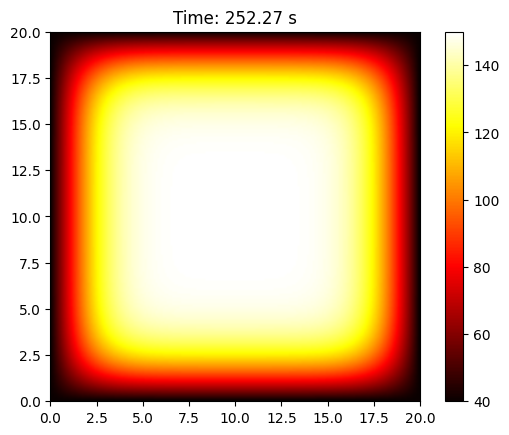

In [8]:
# Visualization setup
fig, ax = plt.subplots()
cax = ax.imshow(U, cmap='hot', origin='lower', extent=[0, Lx, 0, Ly], interpolation='bilinear')
fig.colorbar(cax)

# Animation function
def animate(i):
    global U
    U = step(U, alpha, dx, dy, dt)
    cax.set_array(U)
    ax.set_title(f'Time: {i * dt:.2f} s')
    return cax,

# Create animation
ani = animation.FuncAnimation(fig, animate, frames=nt, interval=50, blit=True)

# Save animation as MP
ani.save('heat_distribution.mp4', writer='ffmpeg', fps=30)

plt.show()


The plot above shows the variation in temperature over time for 2X2 Grid Space, the temperature ranges from $40 \degree C$  to 140 $\degree C$

In [ ]:
fig.savefig('Heat_Distribution.png',format='png')